# ISIC 2018 Task 1: Lesion Segmentation with Mask R-CNN

Instance segmentation of skin lesions using Mask R-CNN (ResNet-50-FPN backbone).

**Dataset:** ISIC 2018 Challenge Task 1 — Lesion Boundary Segmentation  
**Reference:** Codella et al., arXiv:1902.03368, 2019  
**Kaggle dataset:** `tschandl/isic2018-challenge-task1-data-segmentation`

**Model:** `torchvision.models.detection.maskrcnn_resnet50_fpn` pretrained on COCO,  
with box and mask predictor heads replaced for 2 classes (background + lesion).

**Primary metric:** Thresholded Jaccard index (T = 0.65), per Codella et al. (2019).  
Per-image IoU values below T are set to zero before averaging, penalising gross failures.

## 1. Imports and configuration

In [1]:
import random
import os
from pathlib import Path

import numpy as np
import torch
import torch.utils.data
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as TF
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [17]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------
BASE = Path("/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation")

CFG = {
    # Paths
    "img_dir": Path(BASE / "ISIC2018_Task1-2_Training_Input"),
    "mask_dir": Path(BASE / "ISIC2018_Task1_Training_GroundTruth"),
    "ckpt_dir": Path("/kaggle/working/checkpoints"),

    # Data
    "val_fraction": 0.2,       # fraction of training data held out for validation
    "img_size": 512,            # images resized to (img_size x img_size)
    "seed": 42,

    # Training
    "num_classes": 2,           # background (0) + lesion (1)
    "batch_size": 4,
    "num_epochs": 20,
    "lr": 5e-4,
    "weight_decay": 1e-4,
    "lr_step_size": 7,          # StepLR: decay every N epochs
    "lr_gamma": 0.5,

    # Evaluation
    "mask_threshold": 0.5,      # sigmoid threshold for binary mask prediction
    "jaccard_threshold": 0.65,  # Thresholded Jaccard T, per Codella et al. (2019)
    "score_threshold": 0.5,     # minimum detection score to consider
}

CFG["ckpt_dir"].mkdir(parents=True, exist_ok=True)

# Reproducibility
random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])
torch.cuda.manual_seed_all(CFG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Images : {CFG['img_dir']}")
print(f"Masks  : {CFG['mask_dir']}")

Device: cuda
Images : /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1-2_Training_Input
Masks  : /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation/ISIC2018_Task1_Training_GroundTruth


## 2. Dataset

In [18]:
class ISICSegmentationDataset(torch.utils.data.Dataset):
    """
    ISIC 2018 Task 1 lesion segmentation dataset.

    Each sample yields the Mask R-CNN target format:
        image : FloatTensor (3, H, W), values in [0, 1]
        target: dict with keys
            boxes  -- FloatTensor (1, 4), x1 y1 x2 y2 in pixel coords
            labels -- LongTensor  (1,),   always 1 (lesion class)
            masks  -- BoolTensor  (1, H, W)

    Bounding boxes are derived from the tight bounding rectangle of the binary mask. 
    Images with no foreground pixels are skipped at construction time.

    Args:
        img_dir:   Directory containing ISIC_XXXXXXX.jpg files.
        mask_dir:  Directory containing ISIC_XXXXXXX_segmentation.png files.
        img_ids:   List of ISIC IDs (e.g. 'ISIC_0024306') to include.
        img_size:  Both spatial dimensions are resized to this value.
        augment:   If True, apply random horizontal flip augmentation.
    """

    def __init__(self, img_dir: Path,
        mask_dir: Path,
        img_ids: list[str],
        img_size: int = 512,
        augment: bool = False,
    ) -> None:
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment

        # Keep only IDs whose mask contains at least one foreground pixel.
        self.img_ids = self._filter_empty_masks(img_ids)
        print(f"Dataset: {len(self.img_ids)} valid samples "
              f"(removed {len(img_ids) - len(self.img_ids)} empty masks)")

    def _filter_empty_masks(self, img_ids: list[str]) -> list[str]:
        valid = []
        for img_id in img_ids:
            mask_path = self.mask_dir / f"{img_id}_segmentation.png"
            mask = np.array(Image.open(mask_path).convert("L"))
            if mask.max() > 0:
                valid.append(img_id)
        return valid

    def __len__(self) -> int:
        return len(self.img_ids)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, dict]:
        img_id = self.img_ids[idx]

        # Load image as float tensor in [0, 1]
        img = Image.open(self.img_dir / f"{img_id}.jpg").convert("RGB")
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_tensor = TF.to_image(img)                # uint8 (3, H, W)
        img_tensor = TF.to_dtype(img_tensor, dtype=torch.float32, scale=True)

        # Load mask as binary tensor
        mask = Image.open(self.mask_dir / f"{img_id}_segmentation.png").convert("L")
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask_np = (np.array(mask) > 127).astype(np.uint8)  # binary {0, 1}

        # Derive bounding box from mask extent
        rows = np.any(mask_np, axis=1)
        cols = np.any(mask_np, axis=0)
        y1, y2 = np.where(rows)[0][[0, -1]]
        x1, x2 = np.where(cols)[0][[0, -1]]
        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

        target = {
            "boxes":  boxes,
            "labels": torch.ones(1, dtype=torch.long),
            "masks":  torch.from_numpy(mask_np).unsqueeze(0).bool(),
        }

        # Augmentation: random horizontal flip applied consistently to image,
        # mask, and boxes.
        if self.augment and random.random() > 0.5:
            img_tensor = TF.horizontal_flip(img_tensor)
            target["masks"] = TF.horizontal_flip(target["masks"])
            # Flip box: new_x1 = W - old_x2, new_x2 = W - old_x1
            W = self.img_size
            x1_f = W - boxes[0, 2]
            x2_f = W - boxes[0, 0]
            target["boxes"] = torch.tensor(
                [[x1_f, boxes[0, 1], x2_f, boxes[0, 3]]], dtype=torch.float32
            )

        return img_tensor, target

In [19]:
def collate_fn(batch: list[tuple[torch.Tensor, dict]]) -> tuple[list[torch.Tensor], list[dict]]:
    """Collate function for Mask R-CNN: returns lists, not stacked tensors."""
    images, targets = zip(*batch)
    return list(images), list(targets)


def build_dataloaders(cfg: dict) -> tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]:
    """Split training images 80/20 and return train and validation DataLoaders."""
    all_ids = sorted(p.stem for p in cfg["img_dir"].glob("*.jpg"))
    rng = random.Random(cfg["seed"])
    rng.shuffle(all_ids)

    split = int(len(all_ids) * (1 - cfg["val_fraction"]))
    train_ids, val_ids = all_ids[:split], all_ids[split:]

    train_ds = ISICSegmentationDataset(
        cfg["img_dir"], cfg["mask_dir"], train_ids,
        img_size=cfg["img_size"], augment=True,
    )
    val_ds = ISICSegmentationDataset(
        cfg["img_dir"], cfg["mask_dir"], val_ids,
        img_size=cfg["img_size"], augment=False,
    )

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=cfg["batch_size"], shuffle=True,
        num_workers=2, collate_fn=collate_fn, pin_memory=True,
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=1, shuffle=False,
        num_workers=2, collate_fn=collate_fn, pin_memory=True,
    )
    print(f"Train: {len(train_ds)} samples | Val: {len(val_ds)} samples")
    return train_loader, val_loader


train_loader, val_loader = build_dataloaders(CFG)

Dataset: 2075 valid samples (removed 0 empty masks)
Dataset: 519 valid samples (removed 0 empty masks)
Train: 2075 samples | Val: 519 samples


## 3. Dataset sanity check

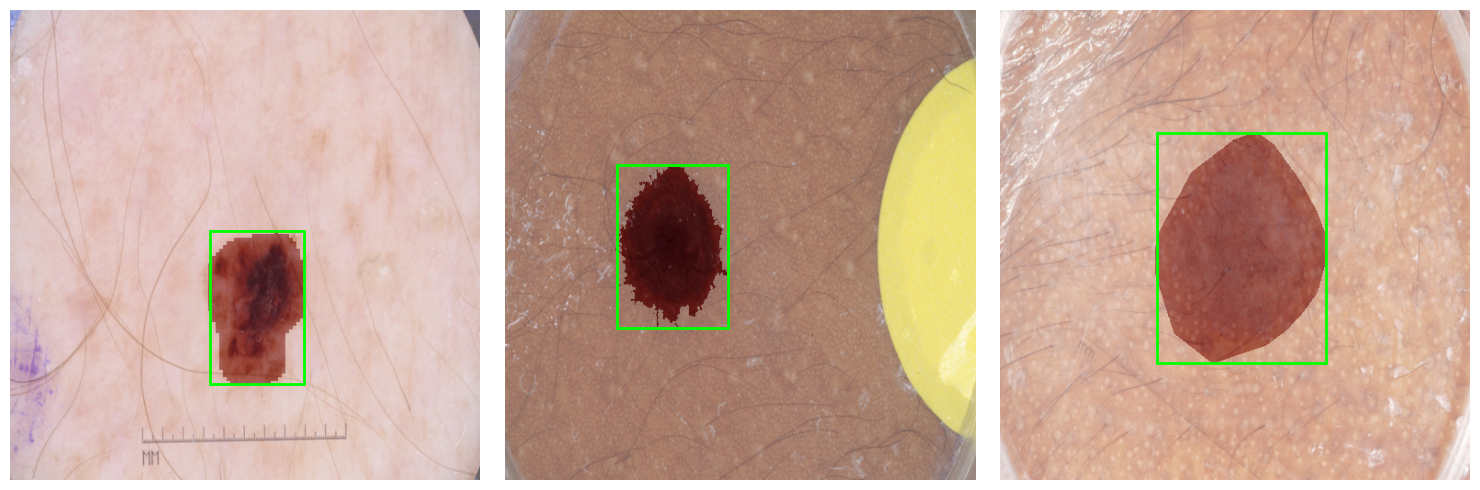

In [20]:
def visualise_sample(loader: torch.utils.data.DataLoader, n: int = 3) -> None:
    """Plot n images with their ground-truth mask and bounding box overlaid."""
    images, targets = next(iter(loader))
    fig, axes = plt.subplots(1, min(n, len(images)), figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, img, tgt in zip(axes, images[:n], targets[:n]):
        # img: (3, H, W) float [0,1]
        ax.imshow(img.permute(1, 2, 0).numpy())
        mask = tgt["masks"][0].numpy()  # (H, W)
        ax.imshow(mask, alpha=0.35, cmap="Reds")
        x1, y1, x2, y2 = tgt["boxes"][0].tolist()
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor="lime", facecolor="none",
        )
        ax.add_patch(rect)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


visualise_sample(train_loader, n=3)

## 4. Model

In [21]:
def build_model(num_classes: int) -> torch.nn.Module:
    """
    Load Mask R-CNN (ResNet-50-FPN) pretrained on COCO and replace the box and mask predictor heads for `num_classes` output classes.

    Both heads are replaced rather than fine-tuned because the output dimension changes (91 COCO classes -> 2 classes). 
    The backbone and FPN weights are retained.

    Args:
        num_classes: Number of output classes including background.

    Returns:
        Mask R-CNN model ready for fine-tuning.
    """
    model = maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Replace box predictor head.
    in_features_box = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)

    # Replace mask predictor head; preserve the hidden dim from the existing head.
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_dim = model.roi_heads.mask_predictor.conv5_mask.out_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_dim, num_classes)

    return model


model = build_model(CFG["num_classes"]).to(DEVICE)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:02<00:00, 81.5MB/s] 


Trainable parameters: 43,699,995


## 5. Evaluation metric: Thresholded Jaccard

In [22]:
def thresholded_jaccard(pred_mask: np.ndarray, gt_mask: np.ndarray, threshold: float = 0.65) -> float:
    """
    Compute Thresholded Jaccard (IoU) for one image pair.

    Standard Jaccard is computed; if it falls below `threshold` it is set to zero, counting the prediction as a gross failure. 
    This is the primary evaluation metric from Codella et al. (2019), with T = 0.65 derived from inter-observer variability on the 2016 challenge data.

    Args:
        pred_mask: Binary predicted mask, shape (H, W), dtype bool or uint8.
        gt_mask:   Binary ground-truth mask, shape (H, W), dtype bool or uint8.
        threshold: Jaccard values below this are zeroed. Default 0.65.

    Returns:
        Thresholded Jaccard value in [0, 1].
    """
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    intersection = (pred & gt).sum()
    union = (pred | gt).sum()
    if union == 0:         # Both masks empty: perfect agreement by convention
        return 1.0
    iou = intersection / union
    return float(iou) if iou >= threshold else 0.0


@torch.no_grad()
def evaluate(model: torch.nn.Module, loader: torch.utils.data.DataLoader, cfg: dict) -> float:
    """
    Evaluate the model on `loader` and return mean Thresholded Jaccard.

    For each image the highest-scoring detection above `score_threshold` is selected as the predicted lesion. 
    If no detection passes the threshold, the predicted mask is all zeros.

    Args:
        model:  Mask R-CNN model in eval mode.
        loader: DataLoader with batch_size=1.
        cfg:    Configuration dict.

    Returns:
        Mean Thresholded Jaccard across all validation images.
    """
    model.eval()
    scores = []

    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        outputs = model(images)  # list of dicts

        for output, target in zip(outputs, targets):
            H, W = images[0].shape[-2:]
            gt_mask = target["masks"][0].numpy()  # (H, W) bool

            # Select the highest-scoring detection above threshold.
            keep = output["scores"] >= cfg["score_threshold"]
            if keep.any():
                best_idx = output["scores"][keep].argmax()
                pred_logit = output["masks"][keep][best_idx, 0]  # (H, W)
                pred_mask = (pred_logit.cpu().numpy() >= cfg["mask_threshold"])
            else:
                pred_mask = np.zeros((H, W), dtype=bool)

            scores.append(
                thresholded_jaccard(
                    pred_mask, gt_mask, cfg["jaccard_threshold"]
                )
            )

    return float(np.mean(scores))

## 6. Training

In [23]:
def train_one_epoch(model: torch.nn.Module, loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer) -> dict[str, float]:
    """
    Run one training epoch.

    Mask R-CNN in train mode returns a loss dict with keys:
        loss_classifier, loss_box_reg, loss_mask, loss_objectness, loss_rpn_box_reg.
    The total loss is their sum.

    Returns:
        Dict of mean loss values for the epoch.
    """
    model.train()
    epoch_losses: dict[str, list[float]] = {}

    for images, targets in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = sum(loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        for k, v in loss_dict.items():
            epoch_losses.setdefault(k, []).append(v.item())
        epoch_losses.setdefault("total", []).append(total_loss.item())

    return {k: float(np.mean(v)) for k, v in epoch_losses.items()}


def train(model: torch.nn.Module, train_loader: torch.utils.data.DataLoader, 
          val_loader: torch.utils.data.DataLoader, cfg: dict) -> dict:
    """
    Full training loop with LR scheduling and best-checkpoint saving.

    Args:
        model:        Mask R-CNN model.
        train_loader: Training DataLoader.
        val_loader:   Validation DataLoader (batch_size=1).
        cfg:          Configuration dict.

    Returns:
        History dict with per-epoch train losses and val Jaccard scores.
    """
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=cfg["lr_step_size"], gamma=cfg["lr_gamma"]
    )

    history = {"train_loss": [], "val_jaccard": []}
    best_jaccard = 0.0

    for epoch in range(1, cfg["num_epochs"] + 1):
        losses = train_one_epoch(model, train_loader, optimizer)
        scheduler.step()
        val_jaccard = evaluate(model, val_loader, cfg)

        history["train_loss"].append(losses["total"])
        history["val_jaccard"].append(val_jaccard)

        print(
            f"Epoch {epoch:02d}/{cfg['num_epochs']} | "
            f"loss_total={losses['total']:.4f} | "
            f"loss_mask={losses.get('loss_mask', 0):.4f} | "
            f"loss_box={losses.get('loss_box_reg', 0):.4f} | "
            f"loss_cls={losses.get('loss_classifier', 0):.4f} | "
            f"val_jaccard={val_jaccard:.4f}"
        )

        if val_jaccard > best_jaccard:
            best_jaccard = val_jaccard
            ckpt_path = cfg["ckpt_dir"] / "best_maskrcnn_isic2018.pth"
            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_jaccard": best_jaccard,
                },
                ckpt_path,
            )
            print(f"  Checkpoint saved (val_jaccard={best_jaccard:.4f})")

    print(f"\nTraining complete. Best val Thresholded Jaccard: {best_jaccard:.4f}")
    return history


history = train(model, train_loader, val_loader, CFG)

Epoch 01/20 | loss_total=0.5199 | loss_mask=0.3488 | loss_box=0.0821 | loss_cls=0.0654 | val_jaccard=0.6767
  Checkpoint saved (val_jaccard=0.6767)
Epoch 02/20 | loss_total=0.3589 | loss_mask=0.2300 | loss_box=0.0701 | loss_cls=0.0442 | val_jaccard=0.6569
Epoch 03/20 | loss_total=0.3325 | loss_mask=0.2144 | loss_box=0.0662 | loss_cls=0.0391 | val_jaccard=0.6946
  Checkpoint saved (val_jaccard=0.6946)
Epoch 04/20 | loss_total=0.3215 | loss_mask=0.2103 | loss_box=0.0632 | loss_cls=0.0364 | val_jaccard=0.7023
  Checkpoint saved (val_jaccard=0.7023)
Epoch 05/20 | loss_total=0.3177 | loss_mask=0.2047 | loss_box=0.0655 | loss_cls=0.0361 | val_jaccard=0.7319
  Checkpoint saved (val_jaccard=0.7319)
Epoch 06/20 | loss_total=0.3035 | loss_mask=0.1975 | loss_box=0.0601 | loss_cls=0.0350 | val_jaccard=0.7320
  Checkpoint saved (val_jaccard=0.7320)
Epoch 07/20 | loss_total=0.2921 | loss_mask=0.1939 | loss_box=0.0573 | loss_cls=0.0313 | val_jaccard=0.7012
Epoch 08/20 | loss_total=0.2666 | loss_mask=

## 7. Training curves

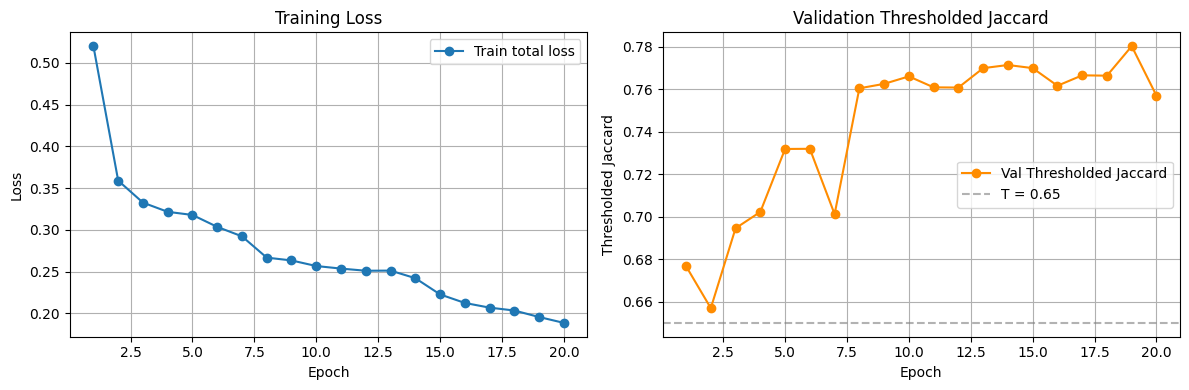

In [24]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], marker="o", label="Train total loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history["val_jaccard"], marker="o", color="darkorange",
         label="Val Thresholded Jaccard")
ax2.axhline(0.65, linestyle="--", color="grey", alpha=0.6, label="T = 0.65")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Thresholded Jaccard")
ax2.set_title("Validation Thresholded Jaccard")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

## 8. Qualitative evaluation on validation set

Loaded checkpoint from epoch 19 (val_jaccard=0.7803)


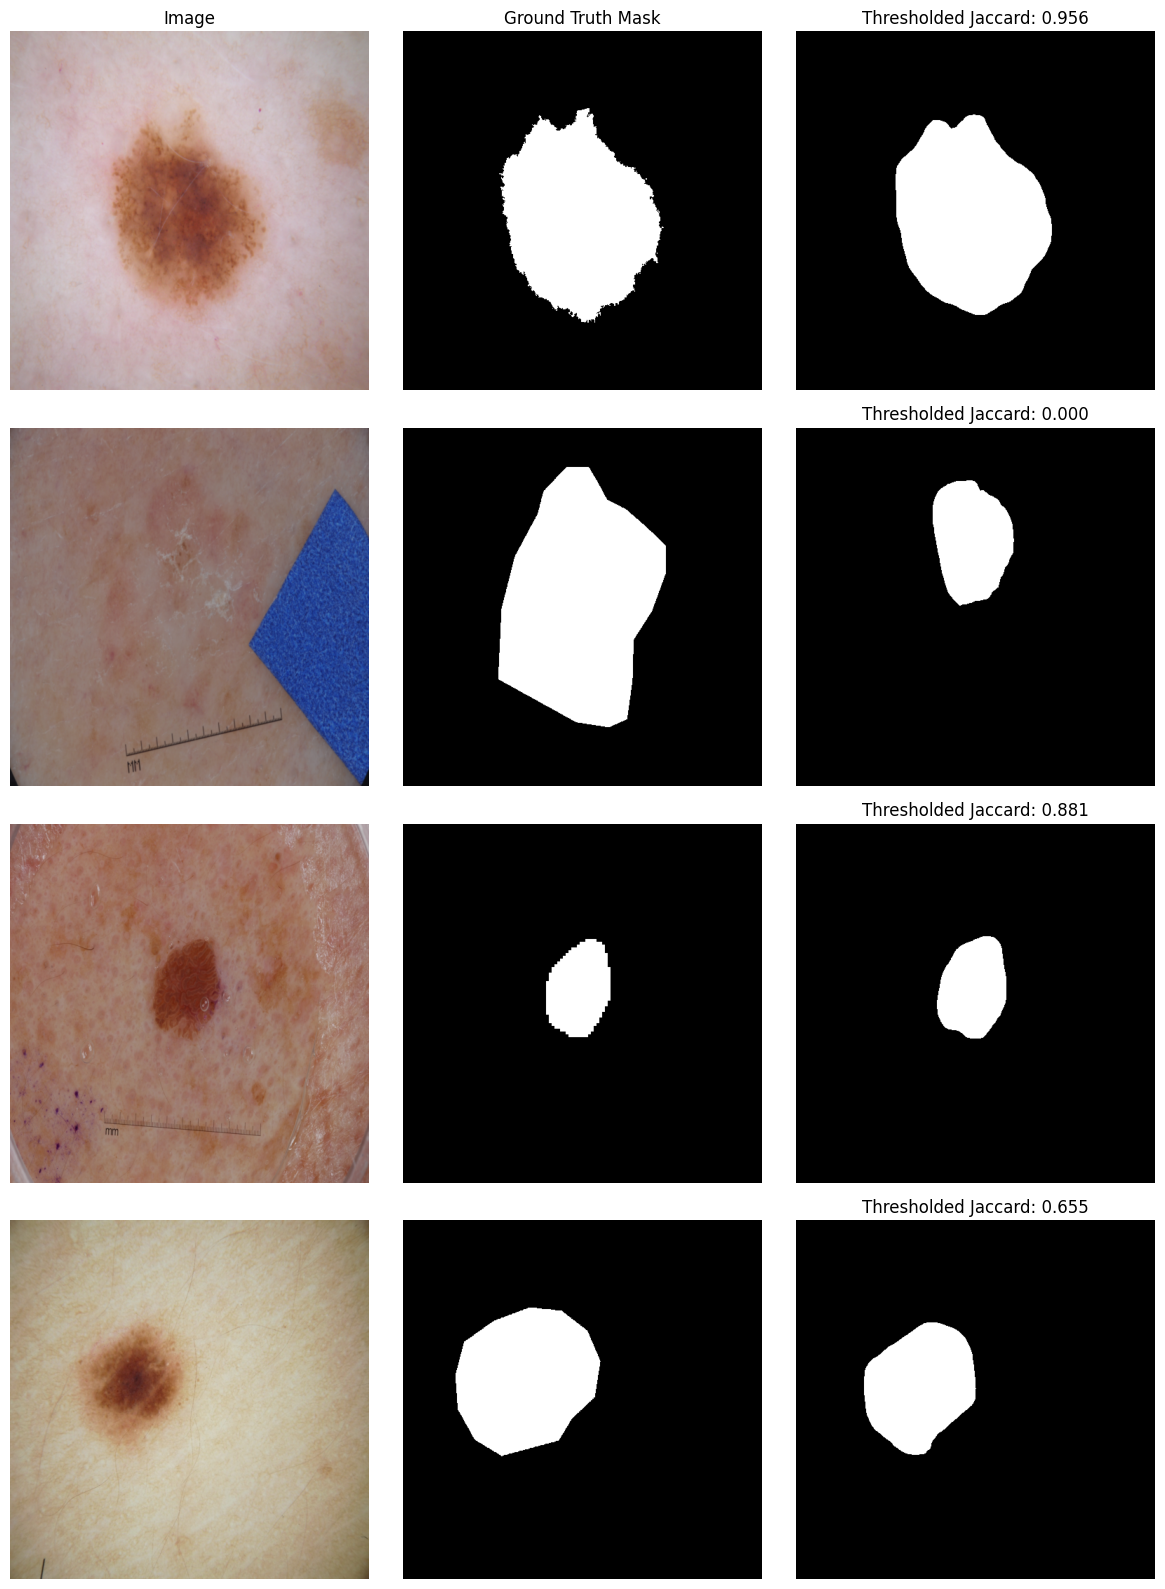

In [25]:
# Load best checkpoint
ckpt = torch.load(CFG["ckpt_dir"] / "best_maskrcnn_isic2018.pth", map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
      f"(val_jaccard={ckpt['val_jaccard']:.4f})")


@torch.no_grad()
def visualise_predictions(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    cfg: dict,
    n: int = 4,
) -> None:
    """Plot n validation images with ground-truth and predicted masks side by side."""
    model.eval()
    samples_shown = 0
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes[0][0].set_title("Image")
    axes[0][1].set_title("Ground Truth Mask")
    axes[0][2].set_title("Predicted Mask")

    for images, targets in loader:
        if samples_shown >= n:
            break
        img_tensor = images[0].to(DEVICE)
        output = model([img_tensor])[0]
        gt_mask = targets[0]["masks"][0].numpy()

        keep = output["scores"] >= cfg["score_threshold"]
        if keep.any():
            best_idx = output["scores"][keep].argmax()
            pred_mask = (
                output["masks"][keep][best_idx, 0].cpu().numpy()
                >= cfg["mask_threshold"]
            )
        else:
            H, W = img_tensor.shape[-2:]
            pred_mask = np.zeros((H, W), dtype=bool)

        iou = thresholded_jaccard(pred_mask, gt_mask, cfg["jaccard_threshold"])

        row = axes[samples_shown]
        row[0].imshow(images[0].permute(1, 2, 0).numpy())
        row[0].axis("off")
        row[1].imshow(gt_mask, cmap="gray")
        row[1].axis("off")
        row[2].imshow(pred_mask, cmap="gray")
        row[2].set_title(f"Thresholded Jaccard: {iou:.3f}")
        row[2].axis("off")

        samples_shown += 1

    plt.tight_layout()
    plt.savefig("/kaggle/working/val_predictions.png", dpi=150)
    plt.show()


visualise_predictions(model, val_loader, CFG, n=4)

## 9. Final validation score

In [26]:
final_jaccard = evaluate(model, val_loader, CFG)
print(f"Final val Thresholded Jaccard (T=0.65): {final_jaccard:.4f}")
print(f"Best val Thresholded Jaccard during training: {ckpt['val_jaccard']:.4f}")

Final val Thresholded Jaccard (T=0.65): 0.7803
Best val Thresholded Jaccard during training: 0.7803
